# fed papers experiment using SVC with linear kernel

# 1 - Imports and Path

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lexos.dtm import DTM, Vectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from lexos.classification import trainer
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer
import lexos.corpus.corpus_stats as cs
from sklearn.model_selection import train_test_split

BASE = Path.cwd() # gets cwd, run this notebook from doc_src/docs/tutorials/classification
DATA = BASE / "fed_papers"

print("Base:", BASE)
print("Data dir exists:", DATA.exists())

/home/mango/Lexos_Independant_Research/lexos/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Base: /home/mango/Lexos_Independant_Research/lexos/doc_src/docs/tutorials/classification
Data dir exists: True


## 2) Collect train and test files

In [2]:
train_dirs = ["HAMILTON", "MADISON"]
test_dirs = ["COAUTHORED", "DISPUTED"]

train_files = []
for d in train_dirs:
    train_files.extend(sorted((DATA / d).glob("*.txt")))

test_files = []
for d in test_dirs:
    test_files.extend(sorted((DATA / d).glob("*.txt")))

print("Train files:", len(train_files), "Test files:", len(test_files))
assert train_files and test_files, "No files found; check working directory and folder structure."

Train files: 65 Test files: 15


## 2.1 Sort files by filename

In [3]:
train_files = sorted(train_files, key=lambda x: x.name)
test_files = sorted(test_files, key=lambda x: x.name)

## 3) Scrubber + Tokenizer

In [4]:
scrubber = Scrubber()
scrubber.add_pipe("lower_case")
scrubber.add_pipe("digits")
scrubber.add_pipe("punctuation")

tokenizer = Tokenizer(model="en_core_web_sm")  # or any installed model

# 4) Split and preprocess data

In [5]:
# Split the data into training and testing sets
train_labels = (
    ["Hamilton"] * len(sorted((DATA / "HAMILTON").glob("*.txt"))) +
    ["Madison"] * len(sorted((DATA / "MADISON").glob("*.txt")))
)
test_labels = (
    ["Coauthored"] * len(sorted((DATA / "COAUTHORED").glob("*.txt"))) +
    ["Disputed"] * len(sorted((DATA / "DISPUTED").glob("*.txt")))
)
# Combine files and labels
data_files = train_files + test_files
labels = train_labels + test_labels

# Ensure the lengths of data_files and labels match
assert len(data_files) == len(labels), f"Mismatch between data_files ({len(data_files)}) and labels ({len(labels)})"

# Split the data
train_data, test_data, train_labels, test_labels = train_test_split(
    data_files, labels, test_size=0.3, random_state=42, stratify=labels
)

# Preprocess the data: read and tokenize
train_docs = [tokenizer(scrubber.scrub(file.read_text())) for file in train_data]
test_docs = [tokenizer(scrubber.scrub(file.read_text())) for file in test_data]


# Create and fit DTM

In [6]:
# initialize the DTM
dtm = DTM()

# fit the DTM on the training data and transform it
train_dtm = dtm.fit_transform(train_docs, train_labels)

# transform the test data
test_dtm = dtm.transform(test_docs) # use vocabualry and term stats learned on training data

# check if the DTM is already normalized
if not dtm.vectorizer.norm:
    scaler = StandardScaler(with_mean=False)  # disable centering for sparse matrices
    train_dtm = scaler.fit_transform(train_dtm)  # fit only on training data
    test_dtm = scaler.transform(test_dtm)  # transform test data

# Train Classifier

In [7]:
from lexos.classification.trainer import fit_classifier
from sklearn.metrics import classification_report

# train the classifier using the preprocessed data
classifier = fit_classifier(
    feature_matrix=train_dtm,
    target_labels=train_labels,
    model="svc",  # Support Vector Classifier
    normalize=None,  # normalization already handled above
    kernel="linear"  # explicitly set the kernel to linear
)

# evaluate the classifier on the test set
predictions = classifier.predict(test_dtm)
report = classification_report(test_labels, predictions)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

  Coauthored       0.00      0.00      0.00         1
    Disputed       0.00      0.00      0.00         4
    Hamilton       0.62      1.00      0.77        15
     Madison       0.00      0.00      0.00         4

    accuracy                           0.62        24
   macro avg       0.16      0.25      0.19        24
weighted avg       0.39      0.62      0.48        24



/home/mango/Lexos_Independant_Research/lexos/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mango/Lexos_Independant_Research/lexos/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mango/Lexos_Independant_Research/lexos/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [8]:
# create a dataframe with actual labels and predictions
results_df = pd.DataFrame({
    'Author': test_labels,
    'Prediction': predictions
})

# Display the table
print(results_df)

        Author Prediction
0     Hamilton   Hamilton
1     Hamilton   Hamilton
2     Disputed   Hamilton
3     Hamilton   Hamilton
4     Disputed   Hamilton
5     Hamilton   Hamilton
6     Hamilton   Hamilton
7     Hamilton   Hamilton
8     Hamilton   Hamilton
9     Hamilton   Hamilton
10    Hamilton   Hamilton
11    Hamilton   Hamilton
12    Hamilton   Hamilton
13    Hamilton   Hamilton
14    Hamilton   Hamilton
15     Madison   Hamilton
16     Madison   Hamilton
17     Madison   Hamilton
18    Hamilton   Hamilton
19    Hamilton   Hamilton
20    Disputed   Hamilton
21     Madison   Hamilton
22  Coauthored   Hamilton
23    Disputed   Hamilton


# Checking feature importance (only feasible for linear kernel)

Top 10 Features by Importance:
Feature 'around': Importance 0.0016251174449301326
Feature 'threw': Importance 0.0016251174449301326
Feature 'finding': Importance 0.0015265151889367306
Feature 'princes': Importance 0.001411167275434745
Feature 'name': Importance 0.0013815562907233182
Feature 'oath': Importance 0.001372679244848632
Feature 'carnage': Importance 0.0013393622923107335
Feature 'disobedient': Importance 0.0013393622923107335
Feature 'conquered': Importance 0.0013393622923107335
Feature 'mischief': Importance 0.0013393622923107335


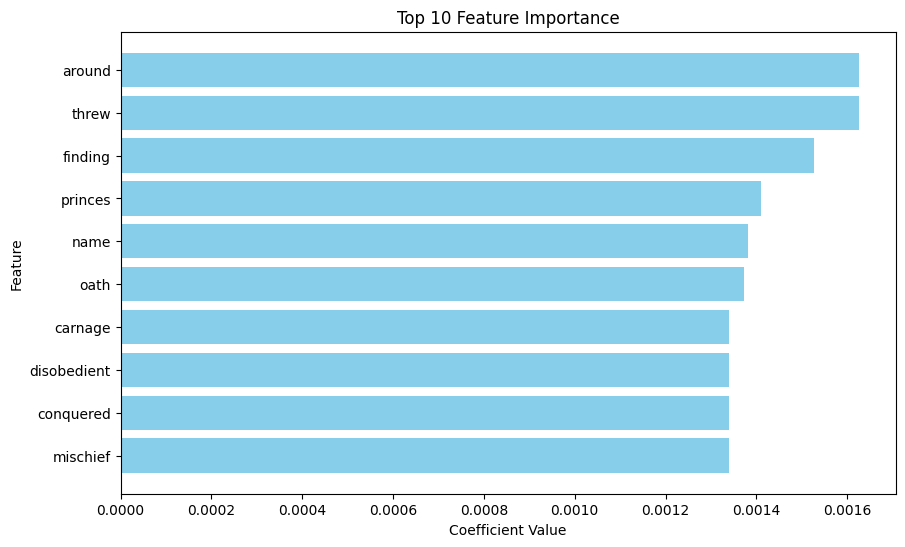

In [9]:
# access feature importance (coefficients) for the linear SVC
feature_importance = classifier.coef_[0]  # For binary classification, use the first class

# convert sparse matrix to dense array if necessary
if hasattr(feature_importance, "toarray"):
    feature_importance = feature_importance.toarray().flatten()

# retrieve feature labels from the DTM's vectorizer
feature_labels = dtm.vectorizer.terms_list

# sort features by importance
sorted_indices = np.argsort(np.abs(feature_importance))[::-1]  # Sort by absolute value
print("Top 10 Features by Importance:")
for idx in sorted_indices[:10]:
    print(f"Feature '{feature_labels[idx]}': Importance {feature_importance[idx]}")

# plot top 10 feature importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
top_10_indices = sorted_indices[:10]
top_10_features = [feature_labels[idx] for idx in top_10_indices]
top_10_importance = [feature_importance[idx] for idx in top_10_indices]
plt.barh(top_10_features, top_10_importance, color="skyblue")
plt.title("Top 10 Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()